### Simple image operations

Image size: 1920x1081


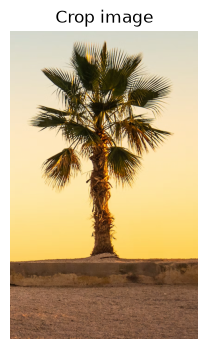

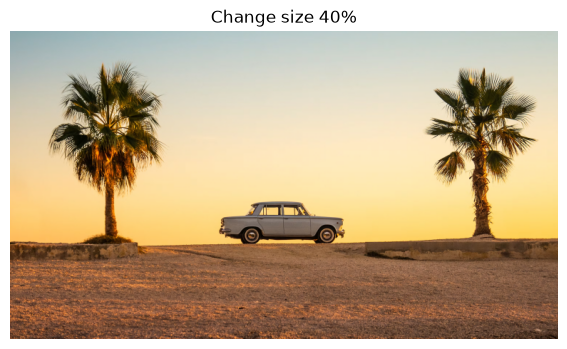

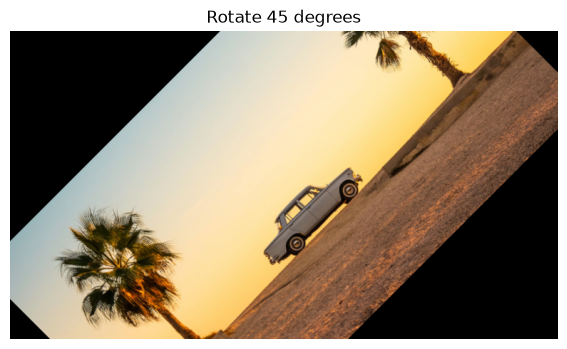

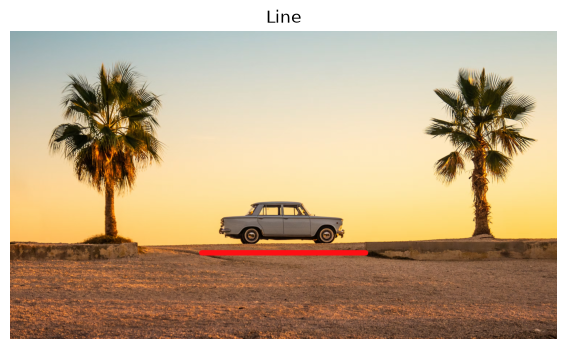

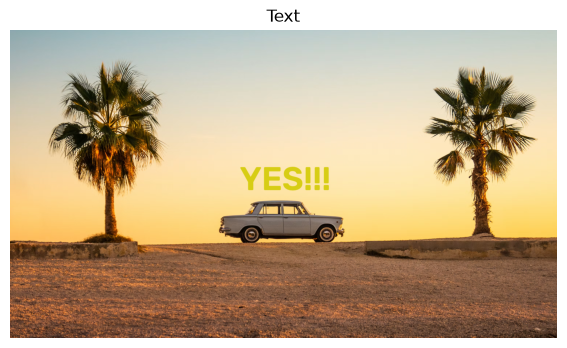

In [16]:
import cv2
import matplotlib.pyplot as plt

image_path = "summer.png"
picture = cv2.imread(image_path)
if picture is None:
    raise FileNotFoundError(f"File '{image_path}' not found. Put it in the current directory.")


# Prepare image for 10920x1080
h, w = picture.shape[:2]
print(f"Image size: {w}x{h}")


def vP(image, title):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 4))
    plt.imshow(image_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()


# 1) Cropping: keep the central part without going beyond the image boundaries
crop_x1, crop_y1 = 1400, 100
crop_x2, crop_y2 = 8500, 950
crop = picture[crop_y1:crop_y2, crop_x1:crop_x2]
vP(crop, "Crop image")

# 2) Resize to 40%
new_w = int(w * 0.4)
new_h = int(h * 0.4)
pict = cv2.resize(picture, (new_w, new_h), interpolation=cv2.INTER_AREA)
vP(pict, "Change size 40%")

# 3) Rotation
center = (new_w // 2, new_h // 2)
rotated = cv2.warpAffine(pict, cv2.getRotationMatrix2D(center, 45, 1), (new_w, new_h))
vP(rotated, "Rotate 45 degrees")

# 4) Line within the image
line_img = picture.copy()
line_start = (int(w * 0.35), int(h * 0.72))
line_end = (int(w * 0.65), int(h * 0.72))
cv2.line(line_img, line_start, line_end, (20, 15, 255), 18)
vP(line_img, "Line")

# 5) Text within the image
text_img = picture.copy()
text_pos = (int(w * 0.42), int(h * 0.52))
cv2.putText(text_img, "YES!!!", text_pos, cv2.FONT_HERSHEY_SIMPLEX, 4, (20, 205, 215), 18)
vP(text_img, "Text")